# Attempt at using a free spectrum regularizer

In [1]:
import discovery as ds
import pathlib
import corner
import matplotlib.pyplot as plt
import discovery.samplers.numpyro as ds_numpyro

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from discovery.models.fourierpta import * 
from discovery.models.flowfourierpta import * 
plt.style.use("matplotlib.mplstyle")

C:\Users\amirt\discovery\src\discovery\models\fourierpta.py:476: SyntaxWarning: invalid escape sequence '\m'
  p(delta t \mid a, theta) p(a \mid \eta_0) p(theta)


In [3]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

npsr = 1
psrfiles= sorted(feathers.glob("*-[JB]*.feather"))[:npsr]
psrs = sorted(
    [ds.Pulsar.read_feather(f) for f in psrfiles],
    key=lambda psr: len(psr.toas), reverse=False
)

In [4]:
eta0_prime_regularizer = [{'log10_rho': jnp.ones(30)*(-6)}]
components = 30


### Standard SPNA run

In [5]:
noisedicts = [psr.noisedict for psr in psrs] # fixed WN
summaries = build_fourier_psr_summaries(
    psrs, eta0_list=eta0_prime_regularizer,
    powerlaw=ds.freespectrum, components=components,
    noisedict_list=noisedicts)

In [6]:
run_step1_model(summaries, priordict_standard, noisedict_list=noisedicts)

[1/1] Running step 1 for B1855+09
[1/1] B1855+09. Theta fixed. Skipping sampler
Computing zero quantities...


In [7]:
summaries[0].is_ready_for_step2

True

In [8]:
samples = run_step2_SPNA(summaries, psrs, ds.partial(phi_SPNA, powerlaw= ds.freespectrum,), priordict_standard,
                    n_warmup=512, n_samples=1024)

[1/1] Running step 2 SPNA for B1855+09


sample: 100%|██████████| 1536/1536 [00:18<00:00, 85.32it/s, 15 steps of size 1.69e-01. acc. prob=0.90] 


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\amirt\AppData\Local\Temp\ipykernel_32192\2871407620.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$i^\mathrm{th}$ component')
C:\Users\amirt\AppData\Local\Temp\ipykernel_32192\2871407620.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


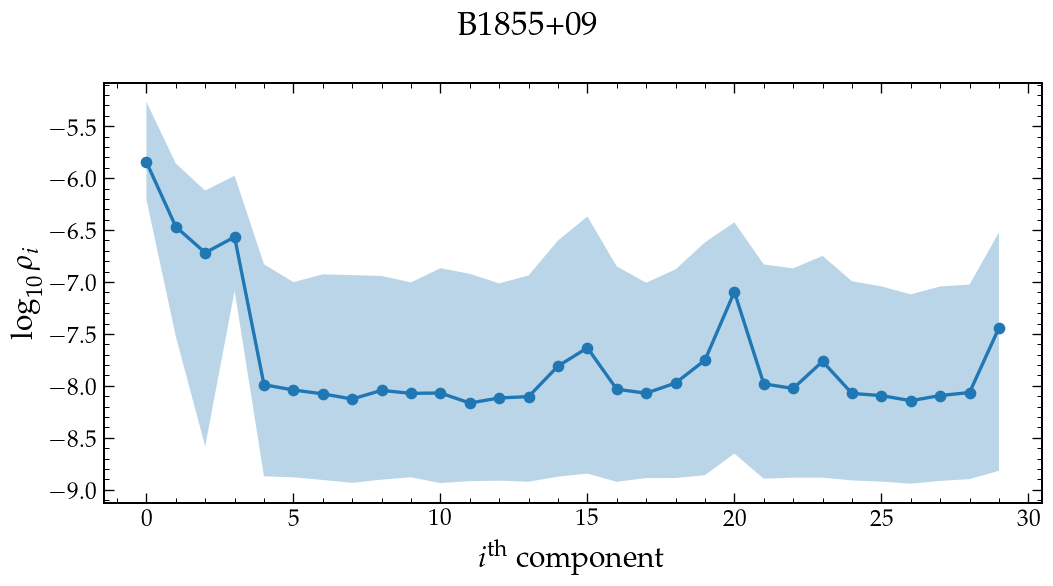

In [16]:
psr_samples = samples[summaries[0].name]
rho_key = [k for k in psr_samples.keys() if 'rho' in k][0]
log10_rho_samp = np.array(psr_samples[rho_key])

n_bins = log10_rho_samp.shape[1]
q05, q50, q95 = np.percentile(log10_rho_samp, [5, 50, 95], axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(np.arange(n_bins), q05, q95, alpha=0.3)
ax.plot(np.arange(n_bins), q50, 'o-')

ax.set_xlabel('$i^\mathrm{th}$ component')
ax.set_ylabel(r'$\log_{10}\rho_i$')
ax.legend()
plt.suptitle(summaries[0].name, fontsize = 20)
plt.tight_layout()
plt.show()

In [31]:
eta0_regularizer = q95 + 0.5*jnp.log(2) # make the prior slightly broader
eta0_regularizer

Array([-4.91826475, -5.51182947, -5.77272411, -5.6297758 , -6.48270679,
       -6.65474169, -6.57939768, -6.58709495, -6.59459397, -6.65711715,
       -6.52038938, -6.57428252, -6.66643678, -6.59008428, -6.25361064,
       -6.02180954, -6.50365144, -6.66013358, -6.53167668, -6.27144547,
       -6.07846335, -6.48413348, -6.52158671, -6.40148248, -6.64613611,
       -6.69540644, -6.77223065, -6.69629409, -6.67794124, -6.175157  ],      dtype=float64)

### Flow run with updated regularizer

In [32]:
summaries = build_fourier_psr_summaries(
    psrs, eta0_list={'log10_rho': eta0_regularizer},
    powerlaw=ds.freespectrum, components=components,
    noisedict_list=noisedicts, # still fixed WN
    psr_class_obj=FlowPulsarFourierSummary)

In [ ]:
run_step1_flow(summaries, priordict=ds.priordict_standard, learning_rate = 1e-2,
               steps = 512, batch_size = 128, n_flow_samples=1000000)

In [ ]:
samples_flow = run_step2_SPNA_flow_corrected(summaries, psrs, ds.partial(phi_SPNA, powerlaw= ds.freespectrum), 
                                        priordict_standard, n_warmup=1024, n_samples=2048)

[1/1] Running step 2 SPNA flow-corrected for B1855+09


sample: 100%|██████████| 3072/3072 [00:43<00:00, 71.35it/s, 15 steps of size 2.07e-01. acc. prob=0.87] 


### Powerlaw models with two different $\log_{10}A$'s

In [23]:
summaries_pl = build_fourier_psr_summaries(
    psrs, eta0_list={'log10_A': -13.0, 'gamma': 1.0},
    powerlaw=ds.powerlaw, components=components,
    noisedict_list=noisedicts, # still fixed WN
    psr_class_obj=FlowPulsarFourierSummary)

In [24]:
run_step1_flow(summaries_pl, priordict=ds.priordict_standard, learning_rate = 1e-2,
               steps = 512, batch_size = 128, n_flow_samples=1000000)

[1/1] Running step 1 for B1855+09
Theta fixed. Using VI.


 26%|██▌       | 132/512 [00:15<00:45,  8.41it/s, loss=-91131.79]


Early stopping at iteration 132
Finished VI flow-fit for pulsar B1855+09.
[1/1]: Running flow step for pulsar B1855+09


In [26]:
samples_flow_pl = run_step2_SPNA_flow_corrected(summaries_pl, psrs, ds.partial(phi_SPNA, powerlaw= ds.powerlaw), 
                                        priordict_standard, n_warmup=1024, n_samples=2048)

[1/1] Running step 2 SPNA flow-corrected for B1855+09


sample: 100%|██████████| 3072/3072 [00:34<00:00, 87.93it/s, 15 steps of size 2.34e-01. acc. prob=0.92] 


In [35]:
summaries_pl_two = build_fourier_psr_summaries(
    psrs, eta0_list={'log10_A': -11.5, 'gamma': 1.0},
    powerlaw=ds.powerlaw, components=components,
    noisedict_list=noisedicts, # still fixed WN
    psr_class_obj=FlowPulsarFourierSummary)

In [36]:
run_step1_flow(summaries_pl_two, priordict=ds.priordict_standard, learning_rate = 1e-2,
               steps = 512, batch_size = 128, n_flow_samples=1000000)

[1/1] Running step 1 for B1855+09
Theta fixed. Using VI.


 26%|██▌       | 132/512 [00:16<00:47,  8.04it/s, loss=-91010.39]


Early stopping at iteration 132
Finished VI flow-fit for pulsar B1855+09.
[1/1]: Running flow step for pulsar B1855+09


In [37]:
samples_flow_pl_two = run_step2_SPNA_flow_corrected(summaries_pl_two, psrs, ds.partial(phi_SPNA, powerlaw= ds.powerlaw), 
                                        priordict_standard, n_warmup=1024, n_samples=2048)

[1/1] Running step 2 SPNA flow-corrected for B1855+09


sample: 100%|██████████| 3072/3072 [00:34<00:00, 88.07it/s, 15 steps of size 2.91e-01. acc. prob=0.86] 


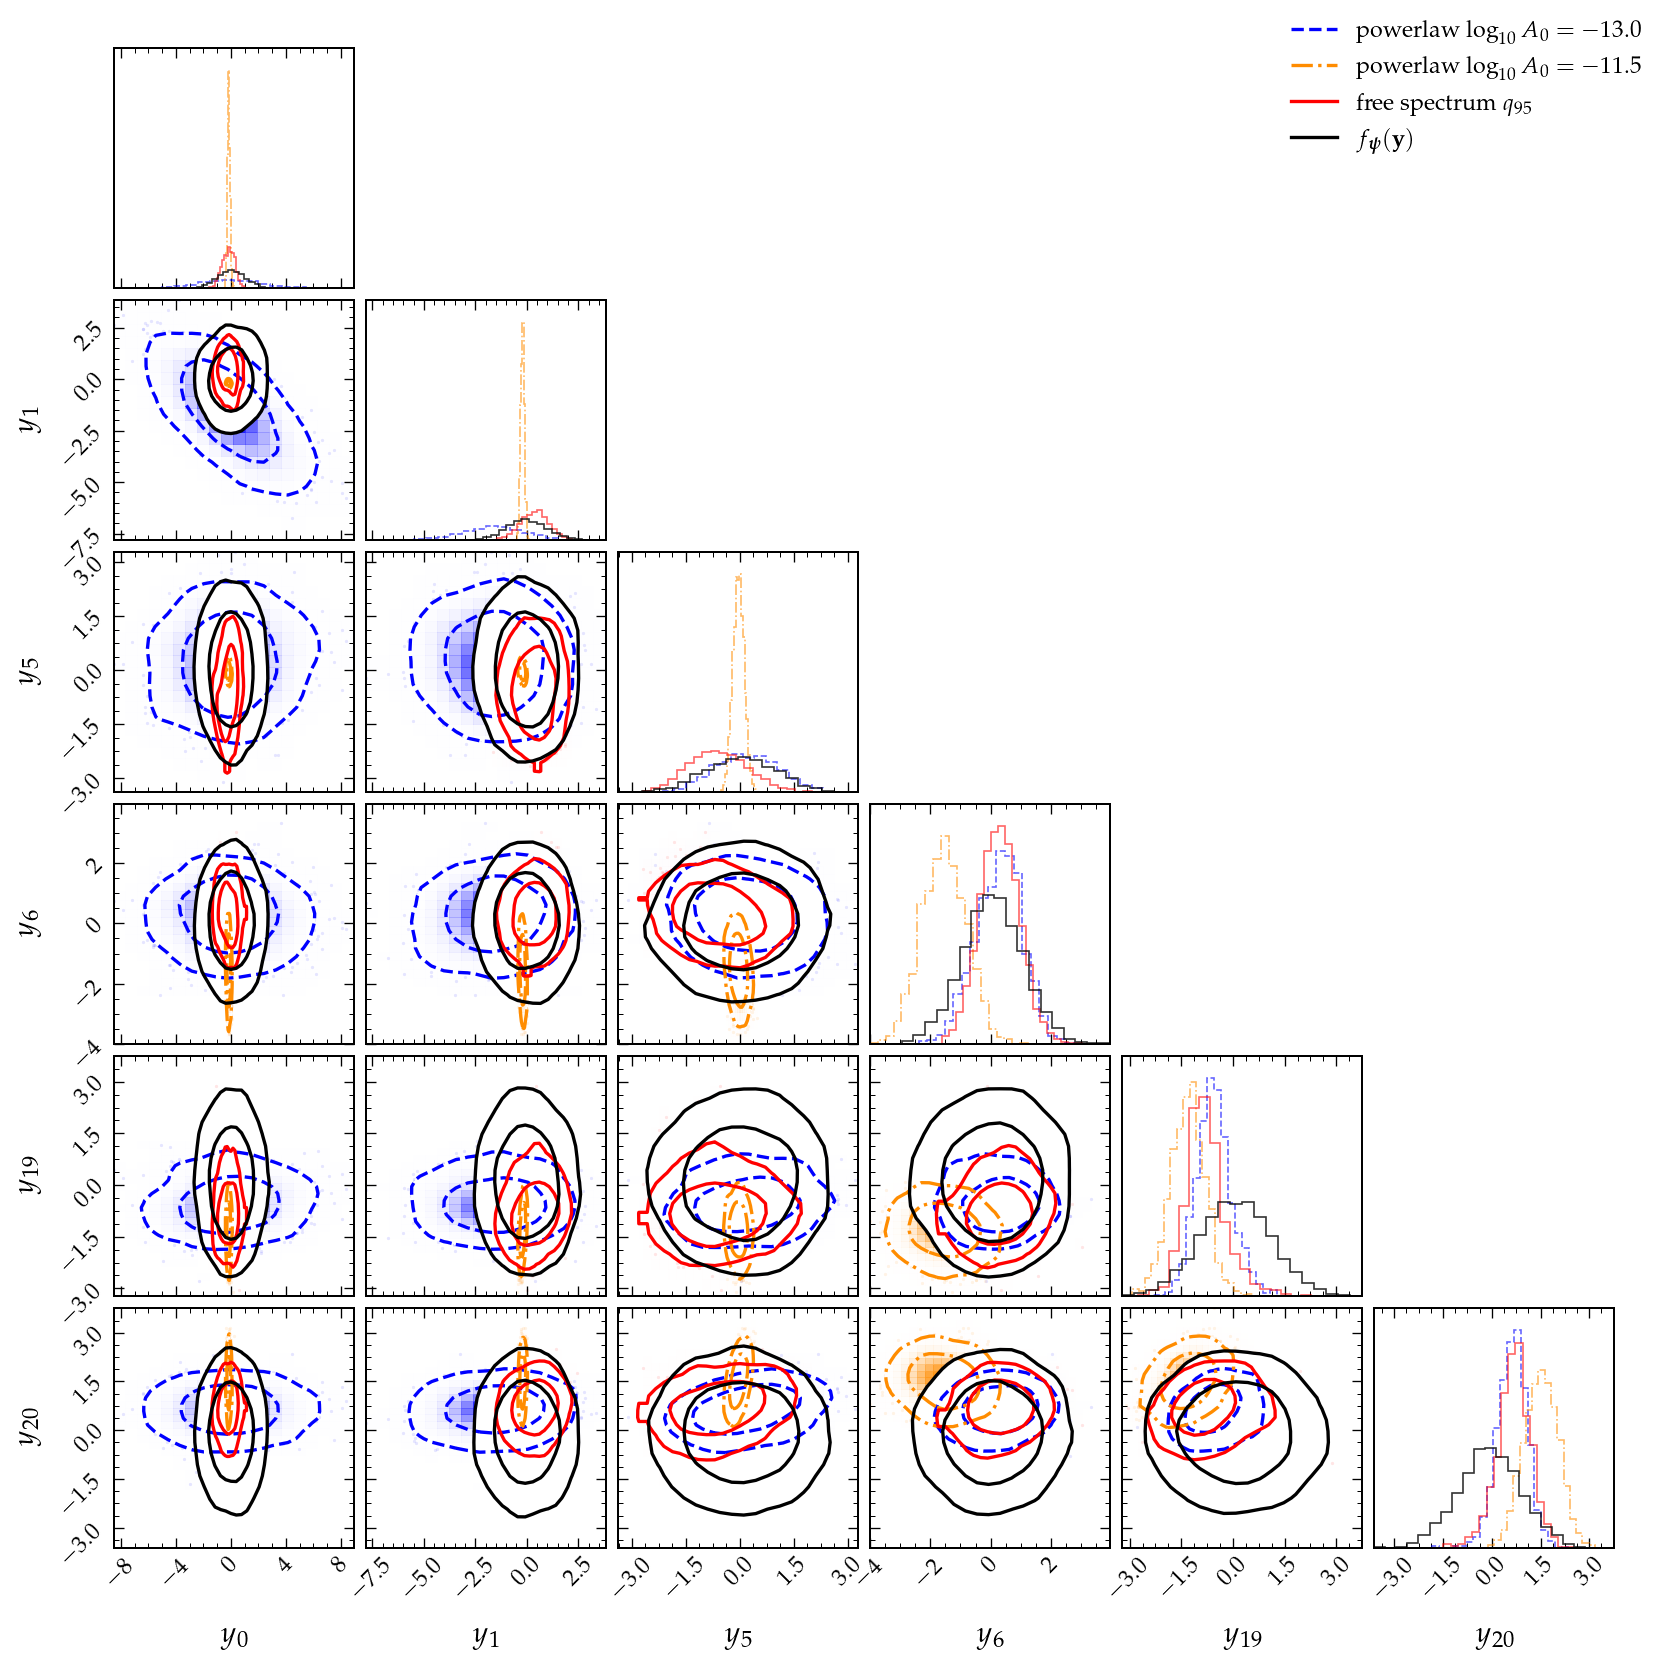

In [ ]:
y_fs = np.array(samples_flow[summaries[0].name]['y'])            
y_plr = np.array(samples_flow_pl[summaries_pl[0].name]['y'])          
y_plr2 = np.array(samples_flow_pl_two[summaries_pl_two[0].name]['y'])  
n_coeff = y_fs.shape[1]

flow_samp = np.array(summaries[0].flow.sample(jax.random.key(0), sample_shape=(4096,)))
y_cols = [0, 1, 5,6, 19, 20]
labels_y = [rf'$y_{{{j}}}$' for j in y_cols]


fig_y = corner.corner(
    y_plr[:, y_cols],
    labels=labels_y,
    color='blue',
    hist_kwargs={"density": True, "alpha": 0.6, "linestyle": "--"},
    contour_kwargs={"linestyles": "--"},
    plot_datapoints=True, plot_density=True, fill_contours=False,
    levels=[0.68, 0.95], smooth=True)

corner.corner(
    y_plr2[:, y_cols],
    labels=labels_y,
    fig=fig_y,
    color='darkorange',
    hist_kwargs={"density": True, "alpha": 0.6, "linestyle": "-."},
    contour_kwargs={"linestyles": "-."},
    plot_datapoints=True, plot_density=True, fill_contours=False,
    levels=[0.68, 0.95], smooth=True)

corner.corner(
    y_fs[:, y_cols],
    labels=labels_y,
    fig=fig_y,
    color='red',
    hist_kwargs={"density": True, "alpha": 0.6},
    plot_datapoints=True, plot_density=True, fill_contours=False,
    levels=[0.68, 0.95], smooth=True)

corner.corner(
    flow_samp[:, y_cols],
    labels=labels_y,
    fig=fig_y,
    color='black',
    hist_kwargs={"density": True, "alpha": 0.8, "linestyle": "-"},
    contour_kwargs={"linestyles": "-"},
    plot_datapoints=False, plot_density=False, fill_contours=False,
    levels=[0.68, 0.95], smooth=True)


legend_elements = [
    plt.Line2D([0], [0], color='blue', linewidth=2, linestyle='--',
               label=r'powerlaw $\log_{10}A_0 = -13.0$'),
    plt.Line2D([0], [0], color='darkorange', linewidth=2, linestyle='-.',
               label=r'powerlaw $\log_{10}A_0 = -11.5$'),
    plt.Line2D([0], [0], color='red', linewidth=2,
               label=r'free spectrum $q_{95}$'),
    plt.Line2D([0], [0], color='black', linewidth=2,
               label=r'$f_\mathrm{\boldsymbol{\psi}}(\mathbf y)$')]
fig_y.legend(handles=legend_elements, loc='upper right')
plt.show()
